# Predicting the used car prices with Machine Learning

# Project Information

This project aims to develop a machine learning soltion to predict the selling price of used cars. The objective is to understand which features drive the most in predicting the price. This will help the Company XYZ to make business strategies , gain valuable insights into market

# Business Questions to Answer (Before Any Model)
These guide every decision you'll make in EDA:

- 1. How Fuel affects the selling price?
- 2. Which Trasmission is more in demand?
- 3. What is the Relationship Between Car Age and Selling Price?
- 4. Selling Price as per Regions
- 5. Top 10 Car Brands by the Number of Cars in the Market?
- 6. How Do Average Selling Prices Vary Across Brands?
- 7. What is the Market Share of the Top 5 Car Brands?
- 8. What is the Correlation Between Different Numeric Features?
- 9. Distribution of Selling Price
- 10. Distribution of how many percentage was sold




# Step 1. Load and explore the data

In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('UsedcarsData.csv')
df

,Sales_ID,Name,Year,Selling_price,km_driven,Region,State or Province,City,Fuel,Seller_type,Transmission,Owner,Mileage,Engine,Max_power,Torque,Seats,Sold
0,3487,Hyundai i20 Asta 1.2,2007,550000,2360457,South,Mississippi,Clinton,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,81.83 bhp,114.7Nm@ 4000rpm,5,N
1,3509,Maruti Wagon R LXI Minor,2010,194000,577414,South,Tennessee,Columbia,Petrol,Individual,Manual,Second Owner,18.9 kmpl,1061 CC,67 bhp,84Nm@ 3500rpm,5,N
2,3642,Maruti Wagon R VXI BS IV,2011,229999,500000,West,Colorado,Denver,Petrol,Individual,Manual,Second Owner,18.9 kmpl,998 CC,67.1 bhp,90Nm@ 3500rpm,5,N
3,999,Maruti Wagon R LXI BS IV,2012,220000,360003,West,California,Los Angeles,Petrol,Individual,Manual,Second Owner,18.9 kmpl,998 CC,67.1 bhp,90Nm@ 3500rpm,5,Y
4,3853,Hyundai Sonata 2.4 GDi MT,2012,550000,330000,West,Colorado,Longmont,Petrol,Individual,Manual,Second Owner,13.44 kmpl,2359 CC,198.25 bhp,250Nm@ 4250rpm,5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7901,1226,Maruti Eeco CNG 5 Seater AC BSIV,2019,450000,10000,Central,Wisconsin,Eau Claire,CNG,Individual,Manual,First Owner,21.94 km/kg,1196 CC,61.7 bhp,85Nm@ 3000rpm,5,Y
7902,36,Maruti Alto 800 CNG LXI Optional,2019,330000,10000,West,Washington,Seattle,CNG,Individual,Manual,Second Owner,33.44 km/kg,796 CC,40.3 bhp,60Nm@ 3500rpm,4,Y
7903,7544,Maruti Alto 800 CNG LXI Optional,2019,330000,10000,Central,Michigan,Mount Pleasant,CNG,Individual,Manual,Second Owner,33.44 km/kg,796 CC,40.3 bhp,60Nm@ 3500rpm,4,N
7904,3307,Maruti Eeco CNG 5 Seater AC BSIV,2020,399000,5000,East,New Hampshire,Merrimack,CNG,Individual,Manual,First Owner,21.94 km/kg,1196 CC,61.7 bhp,85Nm@ 3000rpm,5,N


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7906 entries, 0 to 7905
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sales_ID           7906 non-null   int64 
 1   Name               7906 non-null   object
 2   Year               7906 non-null   int64 
 3   Selling_price      7906 non-null   int64 
 4   km_driven          7906 non-null   int64 
 5   Region             7906 non-null   object
 6   State or Province  7906 non-null   object
 7   City               7906 non-null   object
 8   Fuel               7906 non-null   object
 9   Seller_type        7906 non-null   object
 10  Transmission       7906 non-null   object
 11  Owner              7906 non-null   object
 12  Mileage            7906 non-null   object
 13  Engine             7906 non-null   object
 14  Max_power          7906 non-null   object
 15  Torque             7906 non-null   object
 16  Seats              7906 non-null   int64 


In [4]:
# Get the total rows and columns
df.shape

(7906, 18)

In [5]:
# Check if any null
df.isnull().sum()

Sales_ID             0
Name                 0
Year                 0
Selling_price        0
km_driven            0
Region               0
State or Province    0
City                 0
Fuel                 0
Seller_type          0
Transmission         0
Owner                0
Mileage              0
Engine               0
Max_power            0
Torque               0
Seats                0
Sold                 0
dtype: int64

# Get the overall stats

In [6]:
df.describe().apply(lambda s: s.apply('{:,.2f}'.format))

,Sales_ID,Year,Selling_price,km_driven,Seats
count,"7,906.00","7,906.00","7,906.00","7,906.00","7,906.00"
mean,"4,070.11","2,013.98","649,813.72","69,188.66",5.42
std,"2,345.77",3.86,"813,582.75","56,792.30",0.96
min,1.00,"1,994.00","29,999.00",1.00,2.00
25%,"2,037.25","2,012.00","270,000.00","35,000.00",5.00
50%,"4,076.50","2,015.00","450,000.00","60,000.00",5.00
75%,"6,102.00","2,017.00","690,000.00","95,425.00",5.00
max,"8,128.00","2,020.00","10,000,000.00","2,360,457.00",14.00


# Step 2. Data Preprocessing

In [7]:
# Convert the Age column to vehicles age (Subtract current year(2026) - vechile year)

df['Age'] = pd.Timestamp('now').year - df['Year']


In [8]:
# As the "Brand" value is more, so Just keeping the brand name of the car and stripping out the full name to avoid less noise and converting the column name to brand

df['Name'] = df['Name'].str.split().str[0]
df.rename(columns = {'Name': 'Brand'}, inplace=True)


In [9]:
# Drop the columns which don't add much information

df.drop(columns=['Sales_ID', 'Year', 'State or Province', 'City', 'Torque' ], inplace=True)

In [10]:
df.head()

,Brand,Selling_price,km_driven,Region,Fuel,Seller_type,Transmission,Owner,Mileage,Engine,Max_power,Seats,Sold,Age
0,Hyundai,550000,2360457,South,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,81.83 bhp,5,N,19
1,Maruti,194000,577414,South,Petrol,Individual,Manual,Second Owner,18.9 kmpl,1061 CC,67 bhp,5,N,16
2,Maruti,229999,500000,West,Petrol,Individual,Manual,Second Owner,18.9 kmpl,998 CC,67.1 bhp,5,N,15
3,Maruti,220000,360003,West,Petrol,Individual,Manual,Second Owner,18.9 kmpl,998 CC,67.1 bhp,5,Y,14
4,Hyundai,550000,330000,West,Petrol,Individual,Manual,Second Owner,13.44 kmpl,2359 CC,198.25 bhp,5,N,14


In [11]:
# Keeping the numerics of Mileage, Engine and Max_power 

df['Engine'] = df['Engine'].apply(lambda x: x.split()[0]).astype(int)
df['Mileage'] = df['Mileage'].apply(lambda x: x.split()[0]).astype(float)
df['Max_power'] = df['Max_power'].apply(lambda x: x.split()[0]).astype(float)

# Step 3. EDA (Exploratory Data Analysis)

Text(0, 0.5, 'Selling price in lakhs')

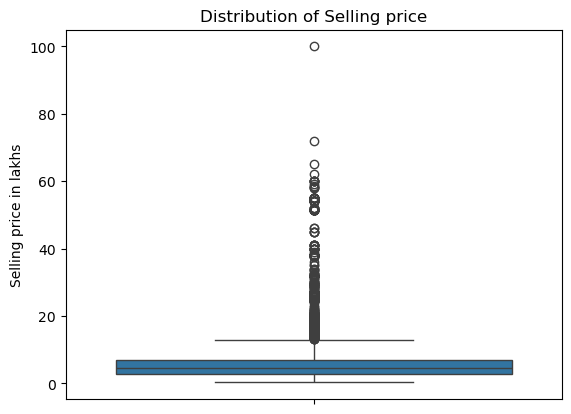

In [12]:
# get the distribution of Selling - prices in lacs

plt.title('Distribution of Selling price')
sns.boxplot(df['Selling_price']/100000)
plt.ylabel('Selling price in lakhs')

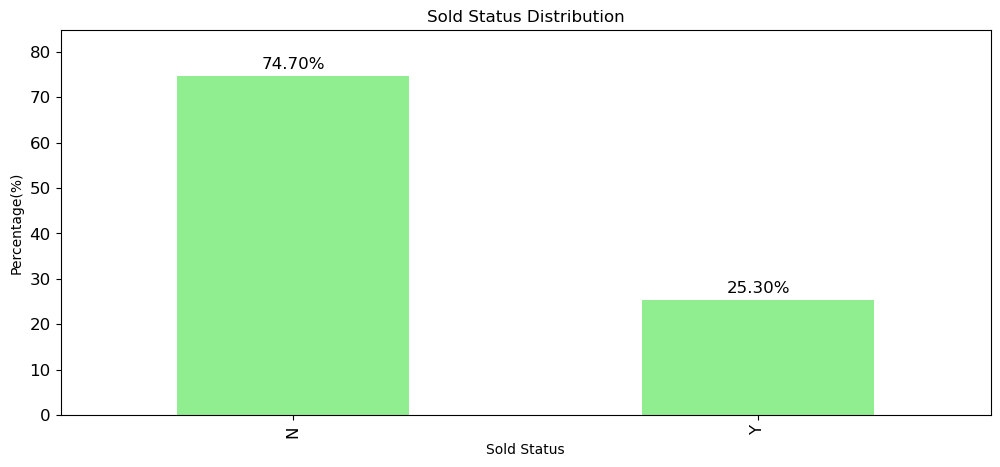

In [13]:
# Get the Sold distribution - Get the % of Not sold and Sold

Sold_distribution = df['Sold'].value_counts(normalize=True)*100

ax = Sold_distribution.plot(kind='bar', figsize=(12,5), fontsize=12, color='lightgreen')

# % sign on top of bar
ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=3, fontsize=12)

# padding so the labels don't get cut off at the top
ax.set_ylim(0, Sold_distribution.max() + 10)

ax.set_xlabel("Sold Status")
ax.set_ylabel("Percentage(%)")
ax.set_title("Sold Status Distribution")
plt.show()


# This Plot shows:
# About 74.70% Cars are not sold & 25.30% cars are sold by the company


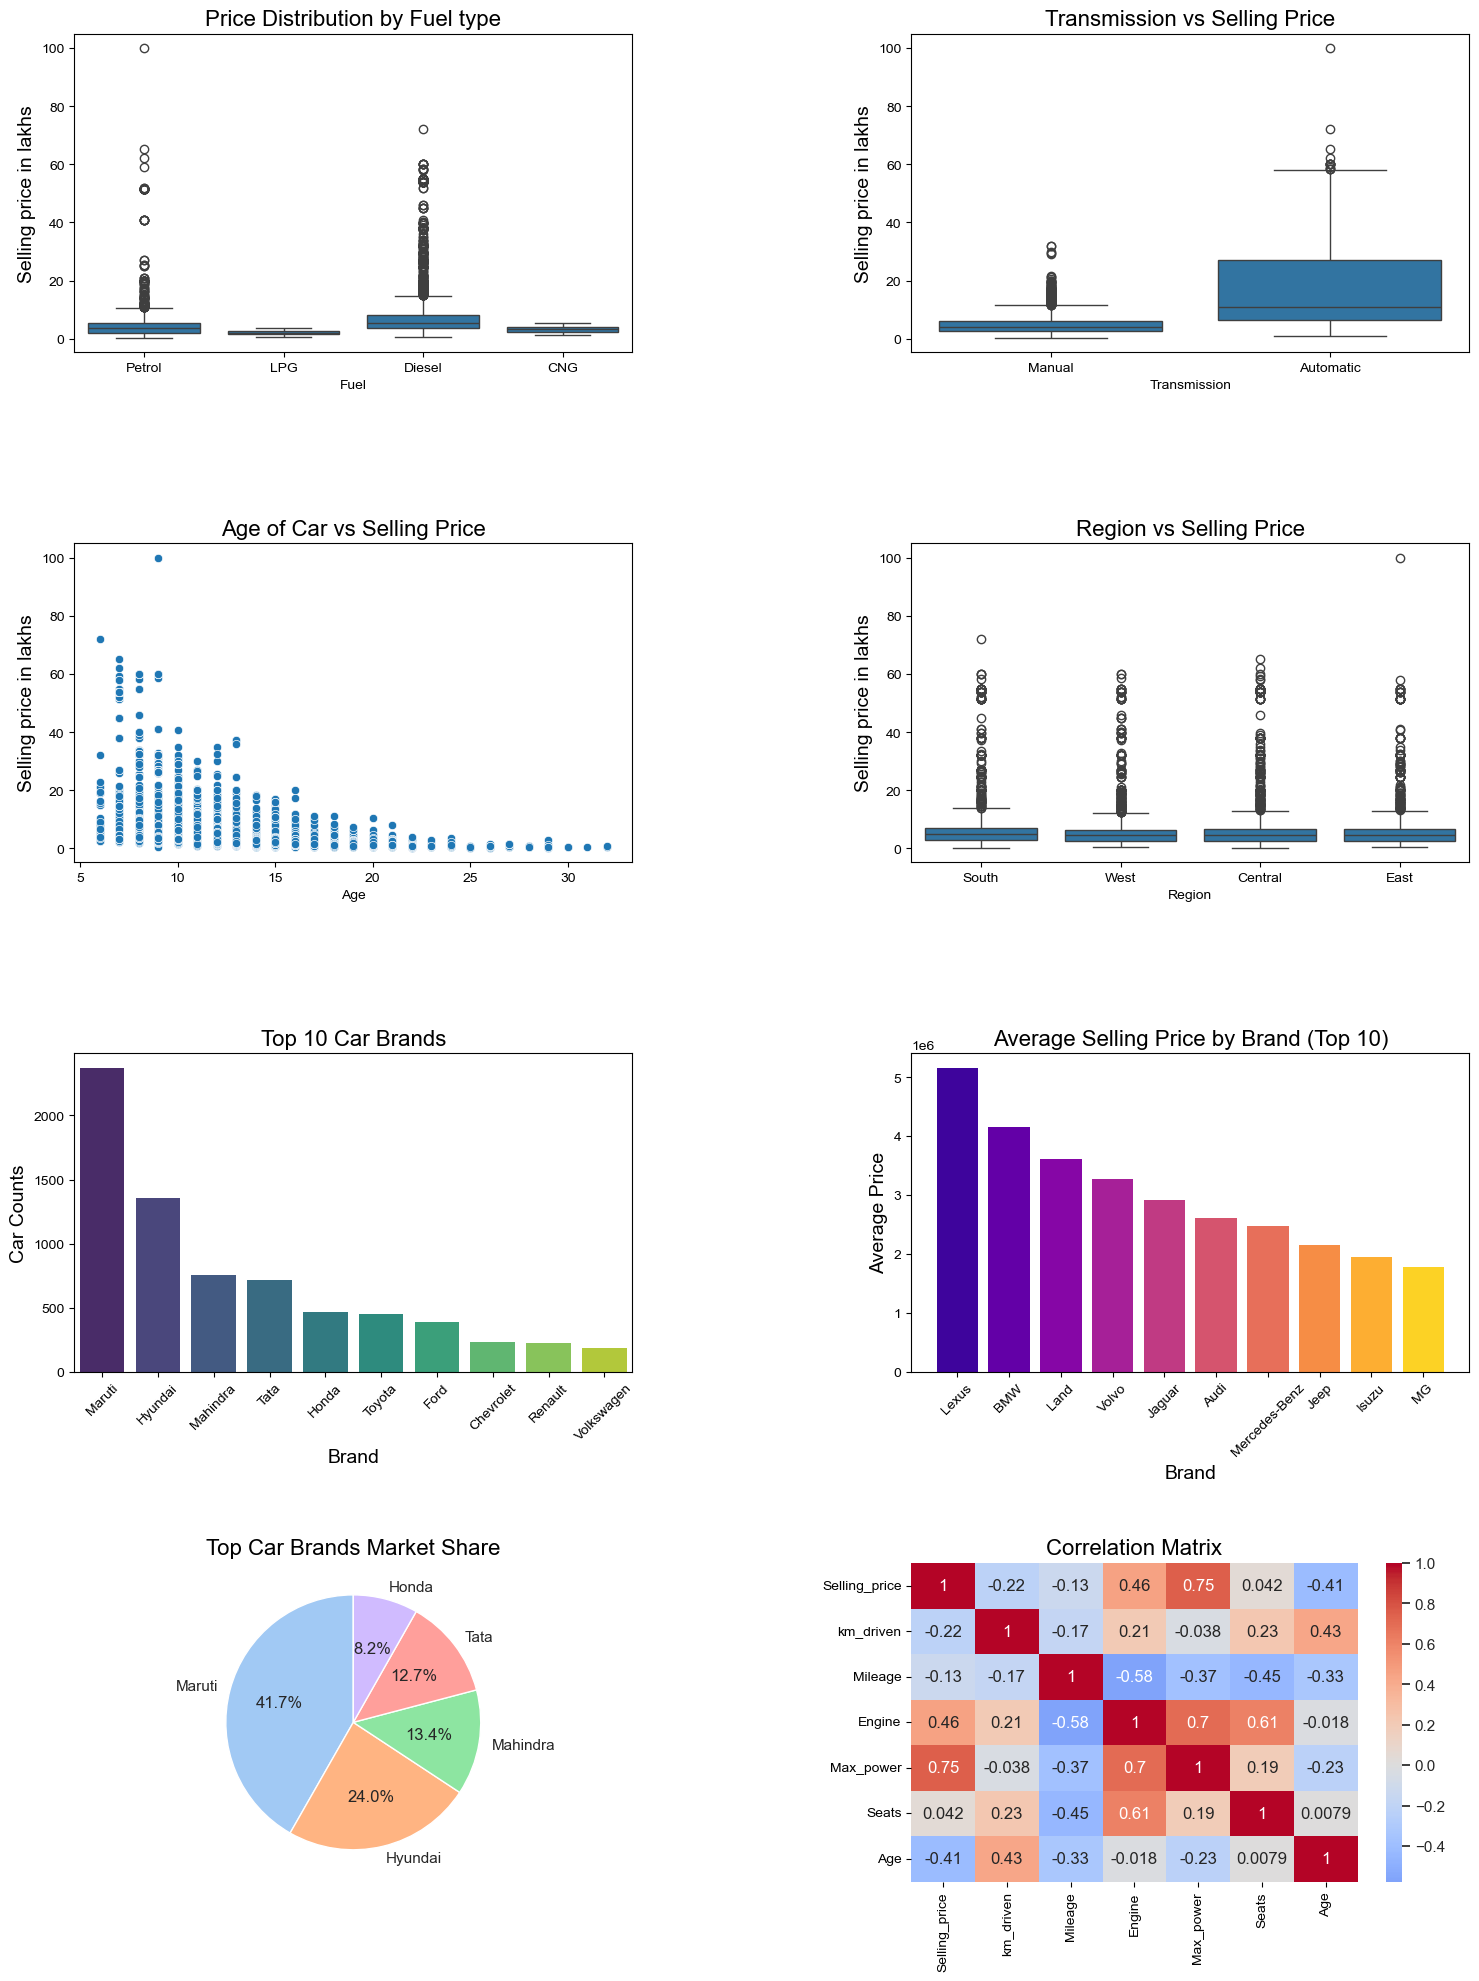

In [14]:
# Create a figure with 4 rows and 2 columns (8 subplots total)
fig, axes = plt.subplots(4,2, figsize=(18,24))
fig.subplots_adjust(hspace=0.6, wspace=0.5)

# Boxplot: Fuel vs Selling_price
sns.boxplot(data=df, x=df['Fuel'], y=df['Selling_price']/100000, ax=axes[0,0])
axes[0,0].set_ylabel('Selling price in lakhs', fontsize=14)
axes[0,0].set_title('Price Distribution by Fuel type',fontsize=16)

# Boxplot: Transmission vs Selling_price
sns.boxplot(data=df, x=df['Transmission'], y=df['Selling_price']/100000, ax=axes[0,1])
axes[0,1].set_ylabel('Selling price in lakhs', fontsize=14)
axes[0,1].set_title('Transmission vs Selling Price',fontsize=16)

# Scatter Plot Car_Age vs Selling_price → depreciation curve
sns.scatterplot(data=df, x=df['Age'], y=df['Selling_price']/100000, ax=axes[1,0])
axes[1,0].set_ylabel('Selling price in lakhs', fontsize=14)
axes[1,0].set_title('Age of Car vs Selling Price',fontsize=16)

# Boxplot: Region vs Selling_price
sns.boxplot(data=df, x=df['Region'], y=df['Selling_price']/100000, ax=axes[1,1])
axes[1,1].set_ylabel('Selling price in lakhs', fontsize=14)
axes[1,1].set_title('Region vs Selling Price',fontsize=16)

# Top 10 brands
top_10_brands = df['Brand'].value_counts().head(10)
sns.barplot(x=top_10_brands.index, y=top_10_brands.values, hue=top_10_brands.index, palette='viridis', ax=axes[2,0])
axes[2,0].set_title('Top 10 Car Brands',fontsize=16)
axes[2,0].set_xlabel('Brand',fontsize=14)
axes[2,0].set_ylabel('Car Counts',fontsize=14)
axes[2,0].tick_params(axis='x', rotation=45)

# Top 10 brands selling price
axes[2,1].bar(df.groupby('Brand')['Selling_price'].mean().sort_values(ascending=False).index[:10], df.groupby('Brand')['Selling_price'].mean().sort_values(ascending=False).values[:10],
               color=sns.color_palette('plasma', n_colors=10))
axes[2, 1].set_title('Average Selling Price by Brand (Top 10)', fontsize=16)
axes[2, 1].set_xlabel('Brand', fontsize=14)
axes[2, 1].set_ylabel('Average Price', fontsize=14)
axes[2, 1].tick_params(axis='x', rotation=45)

# Market share of top 5 brands
top_brands = df['Brand'].value_counts().head(5)
sns.set_theme(style="whitegrid")
colors = sns.color_palette('pastel')[0:len(top_brands)]
axes[3,0].pie(top_brands, labels=top_brands.index , autopct='%1.1f%%', colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'})
axes[3,0].set_title('Top Car Brands Market Share',fontsize=16)

# Cor-relation matrix of all numeric columns
numeric_cols = df.select_dtypes(include=[np.number])
correlation = numeric_cols.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, ax=axes[3, 1])
axes[3, 1].set_title('Correlation Matrix', fontsize=16)

plt.show()

# Key Insights from the  Exploratory Data Analysis

1. **Price Distribution by Fuel type**
- **Diesel cars** are **more expensive** than **petrol cars** due to the **better performance**
- **CNG and LPG** are **highly economical** as they are **less expensive** than petrol and diesel. Meaning drivers get a **cheaper cost-per-kilometer**.

2. **Transmission by Fuel type**
- The cost for buying **automatic cars** is **more expensive** than traditional **manual cars**. There are some **outliers** in automatic cars which pushes the price to **more than 50 lakhs**.

3. **Impact of Car Age on Price**
- As seen from the Scatter Plot, as the **age** of car **increases** the **price value decreases**.
- However, there are **few cars**, which are **old** but still have **high market price** due to their condition.

4. **Impact of Region on Selling Price**
- All the **regions** generally share the **equal pricing values**, which says that region dosen't affect the car price.

5. **Top 10 Brands in India**
- The most popular brands are Maruti, Hyundai, Mahindra
   - **Maruti**: **41.7%** Market Share
   - **Hyndai**: **24.0%** Market Share
   - **Mahindra**: **13.4%** Market Share
- These are top most brands people usually buy.

6. **Top Brands Average Selling Price**
- The **most expensive** cars in Market are **Lexus, BMW, Land Rover**. These are luxurious brands and holds **high market cap**.
- However, the **customer preference** goes more towards the **affordable brands** like **Maruti, Hyundai, Mahindra**

7. **Market Share by brand**
- **Maruti** leads the Market by establishing **41.7%** share, next is **Hyundai** which has **24.0%** of market share and **Mahindra** at **13.4%**
- **Tata** has **12.7%** market cap while **Honda** struggles **8.2%**

8. **Insights from Correlation Matrix**
- **Max power** and **Selling price** are **highly correlated** with a **0.75** score, which shows **high power** cars has **high selling price**.
- **Age** and **Selling Price** shows **high negative correlation** with a **-0.41** score, which shows impact of car's age on Selling price.
- **Engine capacity** and **Mileage** shows **high negative correlation** with a **-0.58** score, which shows that as **high capacity engine** has **low fuel efficiency**.
- **Seats** and **Engine Capacity** shows **high correlation** with a **0.61** score, which **more seats** needs **high capacity engine**.
- **Age** and **Mileage** shows **negative correlation**, which means as **car age increases** the **mileage decreases**

# Step 4. Hypothesis Testing

# We have performed 2 testing. 1) T-test  2) ANOVA Test

- Correlation shows a pattern of numeric columns, Hypothesis tells if the pattern is **Statistically trustworthy**
- We use Hypothesis testing to make sure the relation we see is real and not random noise.

- Below we'll use a **t-test** analysis on **Transmission vs selling price**

- Why **t-test** is used? 
  - Ans: As we don't know the whole population data of the car, we are only working on the sample dataset where STD deviation is not known. Hence, we use t-test.

In [15]:
# We use Independent Two-Sample t-test

# Hypothesis: There is a significant correlation between Transmission and Selling price
# Null Hypothesis (H0): There is no-correlation between Transmission and Selling price
# Alternate Hypothesis (H1): There is correlation between Transmission and Selling price

from scipy import stats

# Make 2 independent groups
manual_price = df[df['Transmission'] == 'Manual']['Selling_price']
automatic_price = df[df['Transmission'] == 'Automatic']['Selling_price']

# perform t-test 
t_stat, p_value = stats.ttest_ind(manual_price, automatic_price, equal_var=False)   # equal_var=false means - test does not assume the two groups have the same variance (performs Welch's t-test)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-value: {p_value:4f}")

# result
if p_value < 0.05:
    print("Reject H0 → Significant price difference between Manual and Automatic")
else:
    print("Fail to reject H0 → No significant price difference")

T-Statistic: -27.8481
P-value: 0.000000
Reject H0 → Significant price difference between Manual and Automatic


In [16]:
# ANOVA check for Region vs Selling price

# Hypothesis: Region has different mean selling price 
# Null Hypothesis (H0): All regions (North, South, East, West) have the same mean selling price — region has no effect on price.
# Alternative Hypothesis (H1): At least one region has a significantly different mean selling price.

import scipy.stats as stats

# Group data by Region on Selling price
region_groups = [group['Selling_price'] for region, group in df.groupby('Region')]

# Perform One-Way ANOVA
f_stats, p_value = stats.f_oneway(*region_groups)

# result
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in car prices between regions.")
else:
    print("Fail to reject null hypothesis: No significant difference in car prices across regions.")

Reject the null hypothesis: There is a significant difference in car prices between regions.


In [17]:
print("Region wise Mean Selling Price")
df.groupby('Region')['Selling_price'].mean().sort_values(ascending=False).round(2)

Region wise Mean Selling Price


Region
South      720585.39
Central    637718.15
East       630165.24
West       625796.12
Name: Selling_price, dtype: float64

# Hypothesis Analysis

- The results matches with the box plot drawn above, which cleary shows that there is a price difference between Automatic cars Manual cars

# T-test summary

- 1. Get mean of each group               → shows the gap
- 2. Get variance of each group           → shows the noise
- 3. Plug into t formula                  → gap ÷ noise = t-statistic
- 4. Calculate df                         → tells which t-curve to use
- 5. Look up p-value using t and df       → probability this is random
- 6. Compare p-value to alpha (0.05)      → decide: real difference or luck?
---------------------------------------------------------------------------------------------------------

# ANOVA Test on Selling price VS Region

- The results show there is difference in the car price value across different Regions.
- However mean difference across regions is less than 1 lakhs which is not harmful and the column could be dropped before model building as it adds, not much information on the region wise sales


# Step 5 Multicollinearity (Essential check in Linear models)

- Multicollinearity: Refers to when 2 or more variables are highly correlated with each other and provides similar information.
- Variance Inflation Factor (VIF) is used to calculate the multicollinearity. If VIF > 5 then columns are highly correlated 

In [18]:
# Compute VIF for numeric columns only

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df[['km_driven', 'Mileage', 'Engine', 'Max_power', 'Seats', 'Age']]  # never include Target column in VIF check

# Constant for accurate regression calculation
X_with_constant = add_constant(X)

# Dataframe for vif results
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns

# Calculate VIF for each feature
vif_data['VIF'] = [variance_inflation_factor(X_with_constant.values, i) for i in range (1,X_with_constant.shape[1])]
print("Variance Inflation Factor (VIF):")
vif_data

Variance Inflation Factor (VIF):


,Feature,VIF
0,km_driven,1.367690
1,Mileage,1.955666
2,Engine,4.232428
3,Max_power,2.792063
4,Seats,2.094654
5,Age,1.688393


# VIF Analysis

- **km_driven, Mileage, Age** has very less VIF score **(VIF < 3)**, indicating these feature can play a role in model training

- **Engine and Max power** has VIF of around **4** has slight high multicollinearity

# Conclusion

- No Major Multicollinearity, all the VIF's are below 5 which will not affect the model training. 
- No action needed yet to drop or combine features.

# Step 6. Model Building

In [19]:
# Drop the column which won't add new information to the model.

df.drop(columns=['Sold', 'Region'], inplace=True)

In [20]:
df.head()

,Brand,Selling_price,km_driven,Fuel,Seller_type,Transmission,Owner,Mileage,Engine,Max_power,Seats,Age
0,Hyundai,550000,2360457,Petrol,Individual,Manual,Second Owner,18.60,1197,81.83,5,19
1,Maruti,194000,577414,Petrol,Individual,Manual,Second Owner,18.90,1061,67.00,5,16
2,Maruti,229999,500000,Petrol,Individual,Manual,Second Owner,18.90,998,67.10,5,15
3,Maruti,220000,360003,Petrol,Individual,Manual,Second Owner,18.90,998,67.10,5,14
4,Hyundai,550000,330000,Petrol,Individual,Manual,Second Owner,13.44,2359,198.25,5,14


In [ ]:
# import necesssary Libraries

import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


#  Step 7. Train-Test split for Encoding

In [22]:
# Target Encoding

X = df.drop('Selling_price', axis=1)
y = df['Selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

# Target encoding for Brand - as there are many unique brands
brand_means = y_train.groupby(X_train['Brand']).mean()
X_train['Brand'] = X_train['Brand'].map(brand_means)
X_test['Brand'] = X_test['Brand'].map(brand_means)
X_test['Brand'] = X_test['Brand'].fillna(y_train.mean())


In [23]:
# Column names strip
X_train.columns = X_train.columns.str.strip()

X_train.columns

Index(['Brand', 'km_driven', 'Fuel', 'Seller_type', 'Transmission', 'Owner',
       'Mileage', 'Engine', 'Max_power', 'Seats', 'Age'],
      dtype='object')

In [24]:
# Label Encoding on Owner-column

owner_mapping = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}

X_train['Owner'] = X_train['Owner'].map(owner_mapping)
X_test['Owner'] = X_test['Owner'].map(owner_mapping)

In [25]:
# 1-hot encoding

ohe_cols = ['Fuel', 'Seller_type', 'Transmission']

X_train = pd.get_dummies(X_train, columns=ohe_cols, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=ohe_cols, drop_first=True, dtype=int)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0) # forces test_data to have same column order as X_train to avoid mismatch while performing encoding


In [26]:
# All are converted to int and flot
X_train.dtypes

Brand                           float64
km_driven                         int64
Owner                             int64
Mileage                         float64
Engine                            int64
Max_power                       float64
Seats                             int64
Age                               int64
Fuel_Diesel                       int64
Fuel_LPG                          int64
Fuel_Petrol                       int64
Seller_type_Individual            int64
Seller_type_Trustmark Dealer      int64
Transmission_Manual               int64
dtype: object

# Step 8. Feature Scaling

In [27]:
X_train.head()

,Brand,km_driven,Owner,Mileage,Engine,Max_power,Seats,Age,Fuel_Diesel,Fuel_LPG,Fuel_Petrol,Seller_type_Individual,Seller_type_Trustmark Dealer,Transmission_Manual
2968,4.118690e+05,15000,1,21.21,1197,81.80,5,9,0,0,1,1,0,0
2439,4.767083e+05,27000,1,20.36,1197,78.90,5,14,0,0,1,1,0,1
1765,4.118690e+05,43000,1,20.85,1197,83.14,5,9,0,0,1,1,0,1
6417,2.693444e+05,60000,1,18.30,1991,147.90,5,16,1,0,0,1,0,1
7691,1.481000e+06,10000,1,20.80,1493,113.40,5,7,1,0,0,1,0,1


In [28]:
# Use ZSCORE to perform feature engineering -- StandardScaler uses Zscore at the 

# Define which columns to scale
cols_to_scale = ['Brand', 'km_driven', 'Owner', 'Mileage', 'Engine', 'Max_power', 'Seats', 'Age']

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [29]:
X_train # after scaling

,Brand,km_driven,Owner,Mileage,Engine,Max_power,Seats,Age,Fuel_Diesel,Fuel_LPG,Fuel_Petrol,Seller_type_Individual,Seller_type_Trustmark Dealer,Transmission_Manual
2968,-0.343677,-1.044396,-0.633864,0.446881,-0.526764,-0.278260,-0.440924,-0.779523,0,0,1,1,0,0
2439,-0.251223,-0.812851,-0.633864,0.236972,-0.526764,-0.359695,-0.440924,0.522633,0,0,1,1,0,1
1765,-0.343677,-0.504125,-0.633864,0.357978,-0.526764,-0.240631,-0.440924,-0.779523,0,0,1,1,0,1
6417,-0.546902,-0.176103,-0.633864,-0.271750,1.045143,1.577916,-0.440924,1.043496,1,0,0,1,0,1
7691,1.180789,-1.140873,-0.633864,0.345631,0.059236,0.609110,-0.440924,-1.300386,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5226,-0.263950,0.402759,-0.633864,-0.096414,-0.004115,0.470108,-0.440924,0.522633,1,0,0,1,0,1
5390,-0.083296,0.306282,-0.633864,1.580392,0.069135,0.193507,-0.440924,-0.519092,1,0,0,1,0,1
860,-0.343677,0.016851,-0.633864,1.123530,-0.920731,-0.692459,-0.440924,0.001771,0,0,1,1,0,1
7603,-0.170582,-1.005805,-0.633864,1.234659,0.069135,0.194349,-0.440924,-1.300386,1,0,0,1,0,1


In [30]:
X_test # after scaling

,Brand,km_driven,Owner,Mileage,Engine,Max_power,Seats,Age,Fuel_Diesel,Fuel_LPG,Fuel_Petrol,Seller_type_Individual,Seller_type_Trustmark Dealer,Transmission_Manual
3641,-0.031862,2.814684,-0.633864,0.395021,-0.004115,-0.775299,-0.440924,0.783065,1,0,0,1,0,1
5531,-0.031862,0.209805,0.776606,-0.849619,2.098360,-0.806189,3.717770,-0.519092,1,0,0,1,0,1
3524,-0.251223,0.981621,-0.633864,0.419716,-1.285001,-1.025223,-0.440924,0.522633,0,1,0,1,0,1
7478,-0.343677,-0.870737,-0.633864,2.222468,-0.425798,-0.496732,-0.440924,-1.300386,1,0,0,1,0,1
3455,-0.170582,-1.237350,0.776606,-0.098884,-0.532703,0.083428,-0.440924,-1.560817,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1317,-0.343677,-0.195398,0.776606,-0.123579,-0.920731,-0.691055,-0.440924,2.085221,0,0,1,1,0,1
622,-0.343677,0.209805,-0.633864,0.274014,-0.920731,-0.692178,-0.440924,0.001771,0,0,1,1,0,1
1419,-0.343677,-0.264379,0.776606,-0.815045,-1.320636,-1.536303,-1.480598,2.345652,0,0,1,1,0,1
4287,-0.031862,0.981621,-0.633864,-0.849619,2.098360,-0.831462,1.638423,0.522633,1,0,0,1,0,1


# Step 9. Model Building

- We are using 3 different Models to compare
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

In [31]:
# define Models

models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree' : DecisionTreeRegressor(random_state=42),
    'Random Forest' : RandomForestRegressor(random_state=42)
}

# Store results
results = []

for name, model in models.items():

    # train the model
    model.fit(X_train, y_train)

    # predict on test
    y_pred = model.predict(X_test)

    # Evaluate 
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results.append({
        'Model': name,
        'R2 Score': round(r2,4),
        'MAE': round(mae,2),
        'MSE': round(mse,2),
        'RMSE': round(rmse,2)
    })

# Display the results
results_df = pd.DataFrame(results)

results_df = results_df.sort_values('R2 Score', ascending=False) # Sort the Model based on R2 score
print(results_df.to_string(index=False))

            Model  R2 Score       MAE          MSE      RMSE
    Random Forest    0.9522  65186.38 3.053948e+10 174755.48
    Decision Tree    0.9465  77030.00 3.417170e+10 184855.90
Linear Regression    0.7998 181518.14 1.279981e+11 357768.26


# Linear Regression — Residual & Homoscedasticity Check

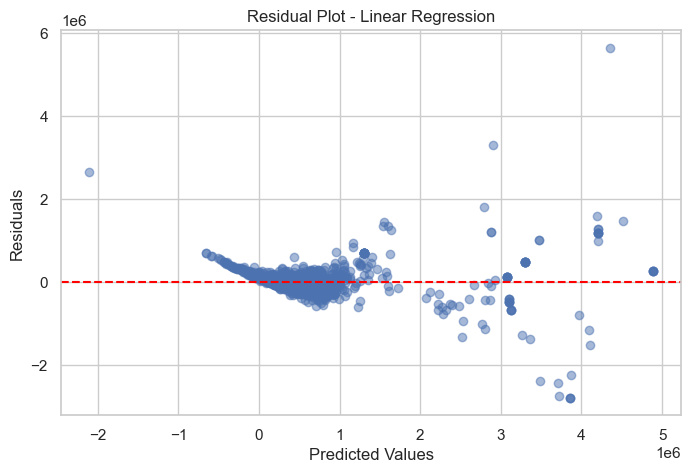

In [32]:
lr_model = models['Linear Regression']
y_pred_lr = lr_model.predict(X_test)
residuals = y_test - y_pred_lr           #actual-predicted

# Residual plot 

plt.figure(figsize=(8,5))
plt.scatter(y_pred_lr, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Linear Regression')
plt.show()

# Analysis of Residual graph

- Residual plot shows funnel pattern where errors are small and consistent for low price cars.
- As the car price increase the the error grows significantly. This is called **Heteroscedasticity**

# R2 Scores of Train and Test of the Models.

- The score shows high training score and low testing score which shows the signs of **"Overfitting"**

In [33]:

print("Decision Tree")
print('Train R²:', r2_score(y_train, models['Decision Tree'].predict(X_train)))
print('Test R²:', r2_score(y_test, models['Decision Tree'].predict(X_test)))

print()
print("Random Forest")
print('Train R²:', r2_score(y_train, models['Random Forest'].predict(X_train)))
print('Test R²:', r2_score(y_test, models['Random Forest'].predict(X_test)))

print()
print("Linear Regression")
print('Train R²:', r2_score(y_train, models['Linear Regression'].predict(X_train)))
print('Test R²:', r2_score(y_test, models['Linear Regression'].predict(X_test)))

Decision Tree
Train R²: 0.9996302601411793
Test R²: 0.9465498210610779

Random Forest
Train R²: 0.996187771008886
Test R²: 0.9522312238094672

Linear Regression
Train R²: 0.8449131632643272
Test R²: 0.79978982855244


# Step 10 - HyperParameter tuning for Decision Tree &  Random Forest using GridSearchCV

In [42]:
# Get the Bydefault parameters used by Decision tree
dt_model = models['Decision Tree']
print(dt_model.get_params())

{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [43]:
from sklearn.model_selection import GridSearchCV
# Use GridSearch CV For decision tree

# define the param grid for Decision Tree regressor
dt_param_grid = {
    'max_depth': [5, 8, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
}   # 3d grid

# Hyperparameter tuning for decision tree
dt_grid_search = GridSearchCV(dt_model, dt_param_grid, cv=5, n_jobs=-1, scoring='r2', verbose=2)

dt_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 8, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='r2', verbose=2)

In [44]:
# Best Decision Tree results 

best_dt_model = dt_grid_search.best_estimator_

# Evaluate the best Decision Tree model on test set
dt_y_pred = best_dt_model.predict(X_test)
print("Best Decision Tree params:",dt_grid_search.best_params_)
print("Train R2                 :", round(dt_grid_search.best_score_, 4))
print("Test R2 Score            :", round(r2_score(y_test, dt_y_pred),4))
print("MAE:                     :",round(mean_absolute_error(y_test, dt_y_pred),2))
print("MSE                      :", round(mean_squared_error(y_test, dt_y_pred), 2))
print("RMSE                     :", round(np.sqrt(mean_squared_error(y_test, dt_y_pred)), 2))

Best Decision Tree params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5}
Train R2                 : 0.9576
Test R2 Score            : 0.9539
MAE:                     : 75688.89
MSE                      : 29473196521.05
RMSE                     : 171677.59


In [ ]:
# Get the Bydefault parameters used by Random Forest
rf_model = models['Random Forest']
print(rf_model.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [46]:
# Use GridSearch CV for Random Forest

# define the param grid for Random Forest regressor

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

# Hyperparameter tuning for Random Forest regressor
rf_grid_search = GridSearchCV(rf_model, rf_param_grid, cv=5, n_jobs=-1, scoring='r2', verbose=2)

rf_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 15, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2', verbose=2)

In [47]:
# Best Random Forest Result

best_rf_model = rf_grid_search.best_estimator_
rf_y_pred = best_rf_model.predict(X_test)

print("Best Random Forest params:", rf_grid_search.best_params_)
print("Train R2                 :", round(rf_grid_search.best_score_, 4))
print("Test R2 Score            :", round(r2_score(y_test, rf_y_pred), 4))
print("MAE                      :", round(mean_absolute_error(y_test, rf_y_pred), 2))
print("MSE                      :", round(mean_squared_error(y_test, rf_y_pred), 2))
print("RMSE                     :", round(np.sqrt(mean_squared_error(y_test, rf_y_pred)), 2))

Best Random Forest params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Train R2                 : 0.9712
Test R2 Score            : 0.9434
MAE                      : 66361.98
MSE                      : 36159313685.31
RMSE                     : 190156.02


# Output of GridSearch CV

- Best Random Forest params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

- Best Decision Tree params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [48]:
# # Comparison Table 

final_comparison = {
    'Model': [
        'Linear Regression',
        'Decision Tree (Baseline)',
        'Decision Tree (Tuned)',
        'Random Forest (Baseline)',
        'Random Forest (Tuned)'
    ],
    'Train R2': [0.8449, 0.9996, 0.9576, 0.9961, 0.9712],
    'Test R2':  [0.7998, 0.9465, 0.9539, 0.9522, 0.9434],
    'MAE':      [181518, 77030,  75688,  65186,  66361],
    'RMSE':     [357768, 184855, 171677, 174755, 190156],
    'Overfit Gap': [0.045, 0.053, 0.003, 0.044, 0.028]
}

final_df = pd.DataFrame(final_comparison)
final_df = final_df.sort_values('Test R2', ascending=False)

final_df.style\
    .highlight_max(subset=['Test R2'], color='lightyellow')\
    .highlight_min(subset=['MAE', 'RMSE', 'Overfit Gap'], color='lightyellow')\
    .format({
        'Train R2': '{:.4f}',
        'Test R2': '{:.4f}',
        'MAE': '{:,.0f}',
        'RMSE': '{:,.0f}',
        'Overfit Gap': '{:.3f}'
    })\
    .hide(axis='index')\
    .set_caption('Final Model Comparison — Baseline vs Tuned')

Model,Train R2,Test R2,MAE,RMSE,Overfit Gap
Decision Tree (Tuned),0.9576,0.9539,"75,688","171,677",0.003
Random Forest (Baseline),0.9961,0.9522,"65,186","174,755",0.044
Decision Tree (Baseline),0.9996,0.9465,"77,030","184,855",0.053
Random Forest (Tuned),0.9712,0.9434,"66,361","190,156",0.028
Linear Regression,0.8449,0.7998,"181,518","357,768",0.045


# Model Evaluation

1. Test R²:
   - **Decision Tree (Tuned)** achieved the **highest R²** of **0.9539** which mean model explains **95%** of used car variation.
   - **Linear Regression** was weakest at **0.7998**, explaining only **80%** of price variation

2. Train R²
   - **Decision Tree (Baseline)** had a near-perfect train **R**² of **0.9996**, which clearly explains **Overfitting**.
   - After **tuning**, this dropped to **0.9576**, confirming the **reduce** in **Overfitting**

3. MAE:
   - **Random Forest (Baseline)** made the **smallest** average prediction **error** of **₹65,186 per car**.
   - **Linear Regression (Baseline)** was the **worst** with an average **error** of **₹1,81,518**

4. RMSE:
   - **Decision Tree (Tuned)** had the **lowest RMSE** of **1,71,677** which means it handles large price errors better than all other models.
   - **Linear Regression (Baseline) struggled** the most with **RMSE** of **3,57,768.**

5. Overfit Gap
   - **Decision Tree (Tuned)** has the **smallest gap** of just **0.003** between train and test R², almost **no Overfitting**.
   - **Decision Tree (Baseline)** has the **worst gap** of **0.053**, confirmed by its near-perfect train R² of **0.9996**.

# Step 11: Feature Importance 

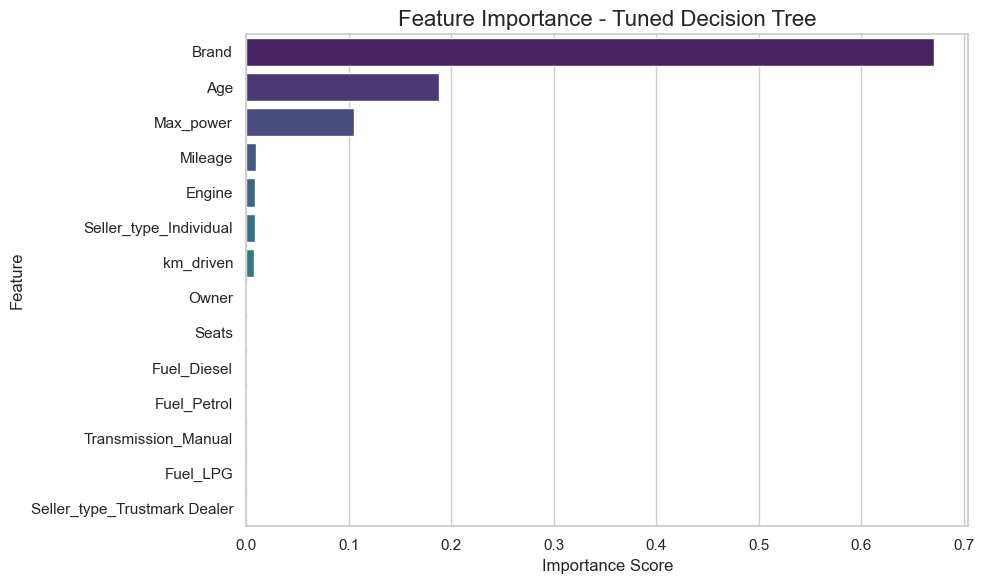

In [49]:
importances = best_dt_model.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances,
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Tuned Decision Tree', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Analysis of Decision Tree Feature importance chart

A used car's price is primarily determined by its brand reputation, age, and engine power. Fuel type, transmission, ownership history, and number of seats have negligible impact on pricing.

# Step 12: Predict on New car

In [57]:
new_car = pd.DataFrame([{
    'Brand': 'Maruti',
    'km_driven': 50000,
    'Owner': 'First Owner',
    'Mileage': 20.0,
    'Engine': 1200.0,
    'Max_power': 80.0,
    'Seats': 5,
    'Age': 5,
    'Fuel_Diesel': 0,
    'Fuel_LPG': 0,
    'Fuel_Petrol': 1,
    'Seller_type_Individual': 1,
    'Seller_type_Trustmark Dealer': 0,
    'Transmission_Manual': 1
}])

In [58]:
# Apply tranformations

# Target encode Brand
new_car['Brand'] = new_car['Brand'].map(brand_means)

# Label encode Owner
new_car['Owner'] = new_car['Owner'].map(owner_mapping)

# Scale numeric columns
new_car[cols_to_scale] = scaler.transform(new_car[cols_to_scale])

# Predict
predicted_price = best_dt_model.predict(new_car)
print(f"Predicted Price: ₹{predicted_price[0]:,.0f}")
print(f"Predicted Price: ₹{predicted_price[0]/100000:.2f} Lakhs")

Predicted Price: ₹371,667
Predicted Price: ₹3.72 Lakhs
